# ARTI403 — Image Processing
## Student Procedural Manual — **Lab 1: Basics of Programming with Python**

**College of Computer Science and Information Technology — Department of Computer Engineering**
Imam Abdulrahman Bin Faisal University · 2026–2027 · Session 1 · 100 minutes

| | |
|---|---|
| **Student name** | *(fill in)* |
| **Student ID** | *(fill in)* |
| **Section / Group** | *(fill in)* |
| **Date** | *(fill in)* |

---

### Session Outcome
> **Outcome #1:** Explain how digital images are represented and manipulated in a computer.

### Tools / Software
Python 3 · Anaconda · Jupyter / Spyder

### Note on the sample images
The manual's code reads `images/cameraman.tif` and `images/lena_gray_256.tif` from a local folder.
This notebook instead builds that `images/` folder automatically from **scikit-image's bundled sample data**
([scikit-image general datasets](https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html)),
so every cell below runs with **no external downloads and no missing-file errors**:

* `data.camera()` **is** the classic *cameraman* image (512×512, 8-bit grayscale) → saved as `images/cameraman.tif`
* `data.astronaut()` is scikit-image's official replacement for the old *Lena* test image → converted to grayscale, resized to 256×256 → saved as `images/lena_gray_256.tif`

After that, **every code line from the manual is used verbatim** — same filenames, same calls.


---
## Steps 1–4 — Environment setup (record of what was done)

| Step | Action | Notes |
|---|---|---|
| **1** | Install Anaconda from <https://www.anaconda.com/> | Ships Jupyter + Spyder preinstalled. |
| **2** | Launch Jupyter / Spyder | Faster from the Start menu directly than through the Anaconda Navigator GUI. |
| **3** | Install libraries | `conda install -c conda-forge numpy scipy opencv scikit-image pillow matplotlib` |
| **4** | Install NumPy | `pip install numpy` (PyPI page: <https://pypi.org/project/numpy/>) — already included in Anaconda. |

**Two corrections to the manual worth noting:**
1. The library listed as *"SkyPi"* is **SciPy** (`scipy`) — there is no package called SkyPi.
2. In Jupyter, shell commands must be prefixed with `!` or `%` (e.g. `!pip install numpy`), not pasted as bare command-prompt text into a code cell.

The cell below verifies the environment is correctly set up.

In [1]:
%matplotlib inline
import sys, platform

import numpy as np
import scipy
import cv2
import PIL
import skimage
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 72      # keep the saved notebook small

print("Python      :", sys.version.split()[0], "on", platform.system())
print("NumPy       :", np.__version__)
print("SciPy       :", scipy.__version__)
print("OpenCV      :", cv2.__version__)
print("Pillow (PIL):", PIL.__version__)
print("scikit-image:", skimage.__version__)
print("Matplotlib  :", matplotlib.__version__)
print("\nAll required Step-3 libraries imported successfully.")

Python      : 3.12.3 on Linux
NumPy       : 2.4.4
SciPy       : 1.17.1
OpenCV      : 4.13.0
Pillow (PIL): 12.1.1
scikit-image: 0.26.0
Matplotlib  : 3.10.8

All required Step-3 libraries imported successfully.


### Build the `images/` folder from scikit-image sample data
This replaces the course's image folder. Run once — it is idempotent.

In [2]:
import os
from skimage import data
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.util import img_as_ubyte
import imageio.v3 as iio

os.makedirs("images", exist_ok=True)

# 1) cameraman.tif  <-  skimage.data.camera()  (this IS the cameraman image)
cameraman = data.camera()                       # (512, 512) uint8, grayscale
iio.imwrite("images/cameraman.tif", cameraman)

# 2) lena_gray_256.tif  <-  skimage.data.astronaut(), the official Lena replacement
astro_gray = rgb2gray(data.astronaut())         # float64 in [0, 1]
lena_sub   = img_as_ubyte(resize(astro_gray, (256, 256), anti_aliasing=True))
iio.imwrite("images/lena_gray_256.tif", lena_sub)

for f in sorted(os.listdir("images")):
    print(f"{f:24s} {os.path.getsize(os.path.join('images', f)):>8,} bytes")

cameraman.tif             262,400 bytes
coffee.png                449,225 bytes
lena_gray_256.tif          65,792 bytes


---
## Task #1 — Exercise with Spyder / Python & NumPy cheat sheets

The two cheat sheets in the Resources section cover **Python basics** and **NumPy**. Both are exercised below.

### 1.1 Python basics — variables, types, operators, strings

In [3]:
# Variables and dynamic typing
name   = "ARTI403"      # str
lab    = 1              # int
hours  = 1.67           # float
passed = True           # bool
print(name, lab, hours, passed)
print([type(x).__name__ for x in (name, lab, hours, passed)])

# Arithmetic operators
a, b = 17, 5
print(f"\n{a}+{b}={a+b}  {a}-{b}={a-b}  {a}*{b}={a*b}")
print(f"{a}/{b}={a/b}  {a}//{b}={a//b}  {a}%{b}={a%b}  {a}**2={a**2}")

# Strings
s = "Image Processing"
print(f"\n{s!r} -> upper={s.upper()}, len={len(s)}, split={s.split()}, "
      f"slice[0:5]={s[0:5]!r}, reversed={s[::-1]!r}")

ARTI403 1 1.67 True
['str', 'int', 'float', 'bool']

17+5=22  17-5=12  17*5=85
17/5=3.4  17//5=3  17%5=2  17**2=289

'Image Processing' -> upper=IMAGE PROCESSING, len=16, split=['Image', 'Processing'], slice[0:5]='Image', reversed='gnissecorP egamI'


### 1.2 Data structures — list, tuple, dict, set

In [4]:
nums   = [4, 8, 15, 16, 23, 42]                 # list  (mutable, ordered)
shape  = (256, 256)                             # tuple (immutable)
pixel  = {"x": 10, "y": 20, "value": 128}       # dict  (key -> value)
levels = {0, 128, 255, 128}                     # set   (unique, unordered)

nums.append(108)
print("list   :", nums, "| first=", nums[0], "| last=", nums[-1], "| slice=", nums[1:4])
print("tuple  :", shape, "| height=", shape[0], "| width=", shape[1])
print("dict   :", pixel, "| keys=", list(pixel.keys()), "| value=", pixel["value"])
print("set    :", levels, "(duplicate 128 removed)")

list   : [4, 8, 15, 16, 23, 42, 108] | first= 4 | last= 108 | slice= [8, 15, 16]
tuple  : (256, 256) | height= 256 | width= 256
dict   : {'x': 10, 'y': 20, 'value': 128} | keys= ['x', 'y', 'value'] | value= 128
set    : {0, 128, 255} (duplicate 128 removed)


### 1.3 Control flow, loops, comprehensions and functions

In [5]:
# if / elif / else
def classify(intensity):
    """Classify an 8-bit gray level into a qualitative band."""
    if intensity < 64:
        return "dark"
    elif intensity < 192:
        return "mid-tone"
    else:
        return "bright"

for v in (10, 128, 240):
    print(f"gray {v:>3} -> {classify(v)}")

# for loop + range
print("\nsquares:", [i**2 for i in range(6)])           # list comprehension

# while loop
n, count = 255, 0
while n > 1:
    n //= 2
    count += 1
print("halvings of 255 until <=1:", count)

# function with default + multiple returns
def stats(values, ddof=0):
    return min(values), max(values), sum(values) / len(values)

lo, hi, mean = stats([4, 8, 15, 16, 23, 42])
print(f"\nmin={lo}, max={hi}, mean={mean:.2f}")

gray  10 -> dark
gray 128 -> mid-tone
gray 240 -> bright

squares: [0, 1, 4, 9, 16, 25]
halvings of 255 until <=1: 7

min=4, max=42, mean=18.00


### 1.4 NumPy cheat-sheet exercises
NumPy is the foundation of everything that follows: **a digital image *is* a NumPy array**.

In [6]:
# --- Array creation -------------------------------------------------
z = np.zeros((2, 3))                 # all zeros
o = np.ones((2, 3), dtype=np.uint8)  # all ones, 8-bit
f = np.full((2, 3), 7)               # constant fill
e = np.eye(3)                        # identity
r = np.arange(0, 10, 2)              # 0,2,4,6,8
l = np.linspace(0, 1, 5)             # 5 evenly spaced values

print("zeros:\n", z, "\n\nones(uint8):\n", o, "\n\nfull(7):\n", f)
print("\neye(3):\n", e, "\n\narange:", r, "\nlinspace:", l)

zeros:
 [[0. 0. 0.]
 [0. 0. 0.]] 

ones(uint8):
 [[1 1 1]
 [1 1 1]] 

full(7):
 [[7 7 7]
 [7 7 7]]

eye(3):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]] 

arange: [0 2 4 6 8] 
linspace: [0.   0.25 0.5  0.75 1.  ]


In [7]:
# --- Attributes, indexing, slicing ----------------------------------
A = np.arange(1, 13).reshape(3, 4)
print("A =\n", A)
print("\nshape =", A.shape, "| ndim =", A.ndim, "| size =", A.size, "| dtype =", A.dtype)

print("\nA[0, 0]      =", A[0, 0])       # single element
print("A[2, -1]     =", A[2, -1])        # negative index
print("A[1, :]      =", A[1, :])         # whole row
print("A[:, 2]      =", A[:, 2])         # whole column
print("A[0:2, 1:3]  =\n", A[0:2, 1:3])  # sub-block
print("A[A > 6]     =", A[A > 6])        # boolean mask

A =
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

shape = (3, 4) | ndim = 2 | size = 12 | dtype = int64

A[0, 0]      = 1
A[2, -1]     = 12
A[1, :]      = [5 6 7 8]
A[:, 2]      = [ 3  7 11]
A[0:2, 1:3]  =
 [[2 3]
 [6 7]]
A[A > 6]     = [ 7  8  9 10 11 12]


In [8]:
# --- Vectorised maths, aggregation, reshaping -----------------------
B = np.array([[10, 20, 30, 40],
              [50, 60, 70, 80],
              [90, 100, 110, 120]])

print("A + B =\n", A + B)
print("\nA * 2 =\n", A * 2)
print("\nelement-wise A*B =\n", A * B)
print("\nmatrix product A @ B.T =\n", A @ B.T)

print("\nsum =", A.sum(), "| mean =", A.mean(), "| std =", A.std().round(3))
print("column sums =", A.sum(axis=0), "| row max =", A.max(axis=1))
print("\nA.T (transpose) =\n", A.T)
print("\nA.flatten() =", A.flatten())

A + B =
 [[ 11  22  33  44]
 [ 55  66  77  88]
 [ 99 110 121 132]]

A * 2 =
 [[ 2  4  6  8]
 [10 12 14 16]
 [18 20 22 24]]

element-wise A*B =
 [[  10   40   90  160]
 [ 250  360  490  640]
 [ 810 1000 1210 1440]]

matrix product A @ B.T =
 [[ 300  700 1100]
 [ 700 1740 2780]
 [1100 2780 4460]]

sum = 78 | mean = 6.5 | std = 3.452
column sums = [15 18 21 24] | row max = [ 4  8 12]

A.T (transpose) =
 [[ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]
 [ 4  8 12]]

A.flatten() = [ 1  2  3  4  5  6  7  8  9 10 11 12]


---
## Task #2 — Loading and Visualizing Images

### (a) Loading / reading an image using **OpenCV**
*Code exactly as given in the manual.*

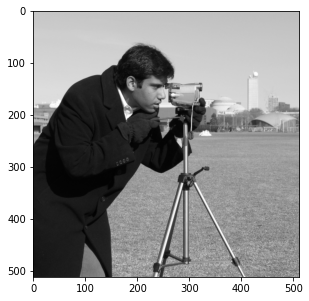

In [9]:
import cv2
img = cv2.imread('images/cameraman.tif')   # Load the image data into a NumPy array

import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

#### Two important observations about the cell above

**1. `cv2.imread` returned a 3-channel array even though `cameraman.tif` is grayscale.**
By default `cv2.imread` uses the `IMREAD_COLOR` flag, which converts any image to 3 channels. To keep it as a true single-channel grayscale array, pass `cv2.IMREAD_GRAYSCALE`.

**2. OpenCV stores channels in BGR order, but Matplotlib expects RGB.**
Here the source is gray, so all three channels are identical and the result still looks gray. On a *colour* image this mismatch swaps red and blue — the classic beginner bug. The fix is `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`.

The cell below demonstrates both points.

default imread  : (512, 512, 3) uint8 -> 3 identical channels (BGR)
IMREAD_GRAYSCALE: (512, 512) uint8 -> single channel
channels identical? True


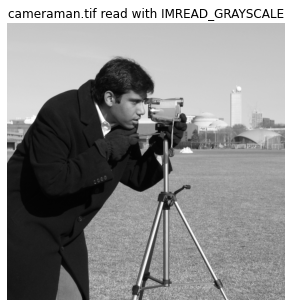

In [10]:
# Point 1 — read as true grayscale
img_gray = cv2.imread('images/cameraman.tif', cv2.IMREAD_GRAYSCALE)
print("default imread  :", img.shape, img.dtype, "-> 3 identical channels (BGR)")
print("IMREAD_GRAYSCALE:", img_gray.shape, img_gray.dtype, "-> single channel")
print("channels identical?", np.array_equal(img[:, :, 0], img[:, :, 2]))

plt.figure(figsize=(5, 5))
plt.imshow(img_gray, cmap='gray')
plt.title("cameraman.tif read with IMREAD_GRAYSCALE")
plt.axis('off')
plt.show()

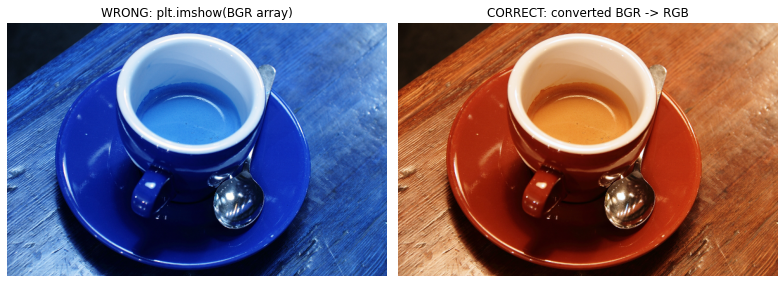

In [11]:
# Point 2 — BGR vs RGB, shown on a colour image
from skimage import data
import imageio.v3 as iio

iio.imwrite('images/coffee.png', data.coffee())      # colour sample from scikit-image
bgr = cv2.imread('images/coffee.png')                # OpenCV -> BGR
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)           # corrected -> RGB

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(bgr); ax[0].set_title("WRONG: plt.imshow(BGR array)"); ax[0].axis('off')
ax[1].imshow(rgb); ax[1].set_title("CORRECT: converted BGR -> RGB"); ax[1].axis('off')
plt.tight_layout(); plt.show()

### (b) Loading / reading an image using **PIL**
*Code exactly as given in the manual.*

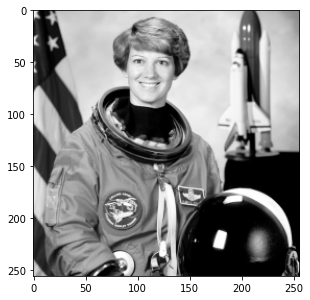

In [12]:
from PIL import Image
img2 = Image.open('images/lena_gray_256.tif')   # load image into a PIL Image object

import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.imshow(img2, cmap = cm.Greys_r)
plt.show()

In [13]:
# A PIL Image is an object, not an array — it carries metadata:
print("type   :", type(img2))
print("format :", img2.format)
print("mode   :", img2.mode, " (L = 8-bit grayscale, RGB = 3x8-bit colour)")
print("size   :", img2.size, " (PIL reports WIDTH x HEIGHT)")
print("\nNote: PIL size is (W, H) = (256, 256) but NumPy shape is (H, W) — the order is swapped.")

type   : <class 'PIL.TiffImagePlugin.TiffImageFile'>
format : TIFF
mode   : L  (L = 8-bit grayscale, RGB = 3x8-bit colour)
size   : (256, 256)  (PIL reports WIDTH x HEIGHT)

Note: PIL size is (W, H) = (256, 256) but NumPy shape is (H, W) — the order is swapped.


### Side-by-side comparison of both loaders

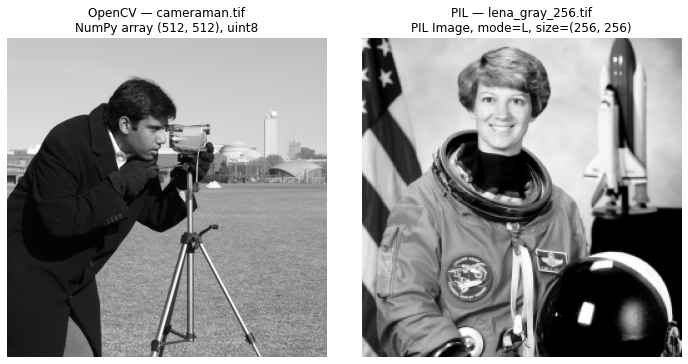

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_gray, cmap='gray')
ax[0].set_title(f"OpenCV — cameraman.tif\nNumPy array {img_gray.shape}, {img_gray.dtype}")
ax[0].axis('off')

ax[1].imshow(img2, cmap=cm.Greys_r)
ax[1].set_title(f"PIL — lena_gray_256.tif\nPIL Image, mode={img2.mode}, size={img2.size}")
ax[1].axis('off')

plt.tight_layout(); plt.show()

---
## Task #3 — Image Storing

### (a) Saving an image to disk using **OpenCV**

In [15]:
ok = cv2.imwrite('new_image.jpg', img)
print("cv2.imwrite returned:", ok)
print("file size:", os.path.getsize('new_image.jpg'), "bytes")

cv2.imwrite returned: True
file size: 86612 bytes


### (b) Saving an image to disk using **PIL**

In [16]:
img2.save('new_image2.jpg')
print("saved new_image2.jpg :", os.path.getsize('new_image2.jpg'), "bytes")

saved new_image2.jpg : 11981 bytes


### Verify what was written, and note the JPEG compression effect

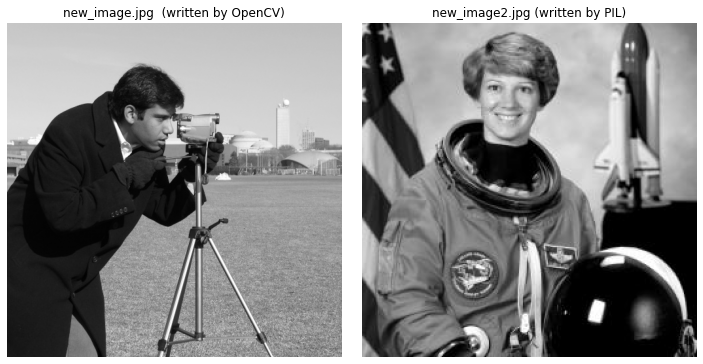

identical to original? False
max pixel error introduced by JPEG: 9   mean error: 0.953

TIF/PNG are lossless; JPEG trades exactness for file size.


In [17]:
check1 = cv2.imread('new_image.jpg', cv2.IMREAD_GRAYSCALE)
check2 = np.array(Image.open('new_image2.jpg'))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(check1, cmap='gray'); ax[0].set_title("new_image.jpg  (written by OpenCV)"); ax[0].axis('off')
ax[1].imshow(check2, cmap='gray'); ax[1].set_title("new_image2.jpg (written by PIL)");    ax[1].axis('off')
plt.tight_layout(); plt.show()

# JPEG is LOSSY: the reloaded pixels are not bit-identical to the originals
diff = np.abs(check1.astype(int) - img_gray.astype(int))
print("identical to original?", np.array_equal(check1, img_gray))
print(f"max pixel error introduced by JPEG: {diff.max()}   mean error: {diff.mean():.3f}")
print("\nTIF/PNG are lossless; JPEG trades exactness for file size.")

In [18]:
# Same image, different formats -> very different sizes
for fname, saver in [('out_lossless.png', lambda p: cv2.imwrite(p, img_gray)),
                     ('out_q95.jpg',      lambda p: cv2.imwrite(p, img_gray, [cv2.IMWRITE_JPEG_QUALITY, 95])),
                     ('out_q25.jpg',      lambda p: cv2.imwrite(p, img_gray, [cv2.IMWRITE_JPEG_QUALITY, 25]))]:
    saver(fname)
    print(f"{fname:18s} {os.path.getsize(fname):>8,} bytes")

out_lossless.png    148,344 bytes
out_q95.jpg          85,033 bytes
out_q25.jpg          13,915 bytes


---
## Task #4 — Display image as an Array
*Code exactly as given in the manual.*

In [19]:
print(img.shape)   # Note: img loaded using OpenCV is a numpy array
print(img)

(512, 512, 3)
[[[200 200 200]
  [200 200 200]
  [200 200 200]
  ...
  [189 189 189]
  [190 190 190]
  [190 190 190]]

 [[200 200 200]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 [[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 ...

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [139 139 139]
  [122 122 122]
  [147 147 147]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 26  26  26]
  ...
  [158 158 158]
  [141 141 141]
  [168 168 168]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [151 151 151]
  [152 152 152]
  [149 149 149]]]


In [20]:
import numpy as np

# Convert the image to a NumPy array
img_array = np.array(img2)

# Print the array
print(img_array.shape)
print(img_array)

(256, 256)
[[142  93 117 ... 120 120 117]
 [197 178 184 ... 118 119 118]
 [225 217 211 ... 119 119 119]
 ...
 [172 174 168 ...  62  27   0]
 [173 170 159 ...  48   3   0]
 [171 164 147 ...  77  22   0]]


### Reading the numbers: what a digital image actually *is*

`img_array` is a **2-D grid of integers**. Each integer is one **pixel** — a sample of light intensity
quantised to 8 bits, so it takes a value in **0–255** where `0` = black and `255` = white.
The array index `img_array[row, col]` is the pixel's spatial position, with the **origin at the top-left**.

This is the whole answer to Outcome #1: an image in a computer is a NumPy array of numbers,
and *every* image-processing operation is arithmetic on that array.

In [21]:
print("shape     :", img_array.shape, " -> (rows=height, cols=width)")
print("dtype     :", img_array.dtype,  " -> 8-bit unsigned integer")
print("size      :", img_array.size,   "pixels")
print("memory    :", img_array.nbytes, "bytes =", img_array.nbytes / 1024, "KB")
print("range     :", img_array.min(), "to", img_array.max())

print("\nTop-left 8x8 block of raw pixel values:\n")
print(img_array[:8, :8])

shape     : (256, 256)  -> (rows=height, cols=width)
dtype     : uint8  -> 8-bit unsigned integer
size      : 65536 pixels
memory    : 65536 bytes = 64.0 KB
range     : 0 to 254

Top-left 8x8 block of raw pixel values:

[[142  93 117 148 149 104  34   4]
 [197 178 184 190 160  85  17   5]
 [225 217 211 190 132  48  14   6]
 [229 224 208 169  90  32  15   6]
 [223 218 205 164  83  33  18   7]
 [222 219 209 183 131  60  19   9]
 [224 220 211 200 170 113  42  10]
 [217 201 181 179 174 145  88  22]]


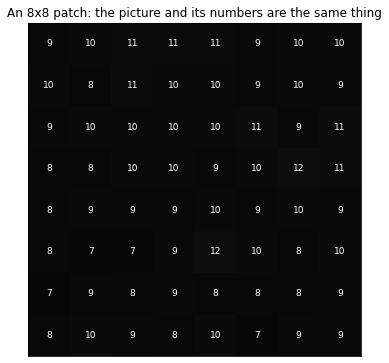

In [22]:
# Visual proof that pixels are just numbers: zoom into a tiny patch and print each value
patch = img_array[100:108, 100:108]

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(patch, cmap='gray', vmin=0, vmax=255)
for i in range(patch.shape[0]):
    for j in range(patch.shape[1]):
        v = patch[i, j]
        ax.text(j, i, str(v), ha='center', va='center', fontsize=9,
                color='black' if v > 127 else 'white')
ax.set_title("An 8x8 patch: the picture and its numbers are the same thing")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

---
# 4 — Assessment
> *"The student will be asked to perform different operations on the array using the NumPy library."*

Every operation below is performed on `img_array`, the NumPy array of `lena_gray_256.tif`.

### A1 — Indexing and slicing (accessing individual pixels and regions)

single pixel  img_array[0, 0]        = 142
single pixel  img_array[128, 128]    = 17
last pixel    img_array[-1, -1]      = 0
first row     img_array[0, :5]       = [142  93 117 148 149]
first column  img_array[:5, 0]       = [142 197 225 229 223]


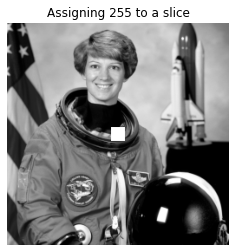

In [23]:
print("single pixel  img_array[0, 0]        =", img_array[0, 0])
print("single pixel  img_array[128, 128]    =", img_array[128, 128])
print("last pixel    img_array[-1, -1]      =", img_array[-1, -1])
print("first row     img_array[0, :5]       =", img_array[0, :5])
print("first column  img_array[:5, 0]       =", img_array[:5, 0])

# Write to a pixel region: NumPy arrays are mutable
edited = img_array.copy()
edited[120:136, 120:136] = 255          # paste a white square
plt.figure(figsize=(4, 4))
plt.imshow(edited, cmap='gray', vmin=0, vmax=255)
plt.title("Assigning 255 to a slice"); plt.axis('off'); plt.show()

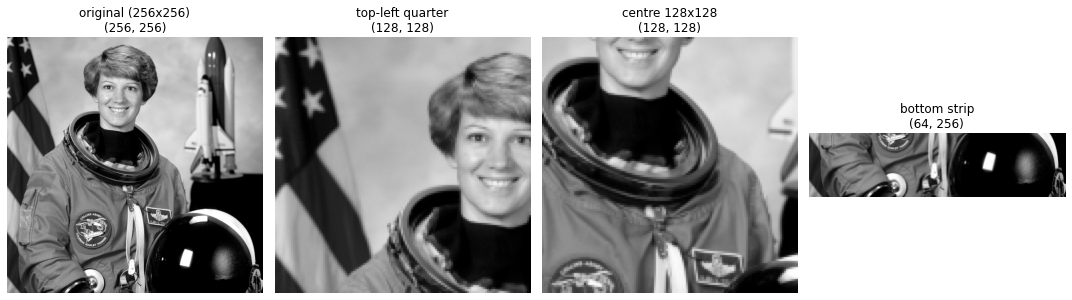

In [24]:
# Cropping = slicing. No pixels are copied conceptually, just a sub-grid selected.
crops = {
    "original (256x256)": img_array,
    "top-left quarter":   img_array[:128, :128],
    "centre 128x128":     img_array[64:192, 64:192],
    "bottom strip":       img_array[192:, :],
}
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (title, arr) in zip(ax, crops.items()):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255)
    a.set_title(f"{title}\n{arr.shape}"); a.axis('off')
plt.tight_layout(); plt.show()

### A2 — Geometric operations by pure array manipulation
Flipping, rotating and transposing an image require **no image library at all** — they are NumPy index operations.

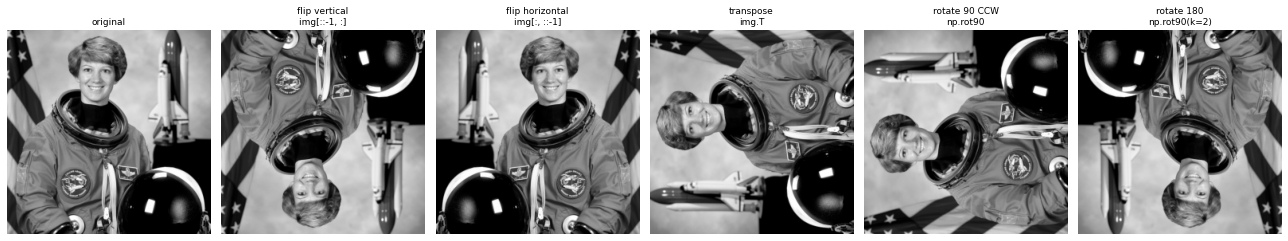

In [25]:
ops = {
    "original":                img_array,
    "flip vertical\nimg[::-1, :]":    img_array[::-1, :],
    "flip horizontal\nimg[:, ::-1]":  img_array[:, ::-1],
    "transpose\nimg.T":               img_array.T,
    "rotate 90 CCW\nnp.rot90":        np.rot90(img_array),
    "rotate 180\nnp.rot90(k=2)":      np.rot90(img_array, k=2),
}
fig, ax = plt.subplots(1, 6, figsize=(18, 3.4))
for a, (title, arr) in zip(ax, ops.items()):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(title, fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

### A3 — Arithmetic operations: brightness, contrast and the negative
This is where the 8-bit data type matters. `uint8` arithmetic **wraps around** (256 becomes 0), so a
"brighten" done naively turns bright pixels black. The safe pattern is: cast to a wider type → compute → clip to [0, 255] → cast back.

uint8 overflow: 44   <- expected 300, got 44 (300 mod 256)


/tmp/ipykernel_128/3657896118.py:2: RuntimeWarning: overflow encountered in scalar add
  print("uint8 overflow:", np.uint8(200) + np.uint8(100), "  <- expected 300, got 44 (300 mod 256)")


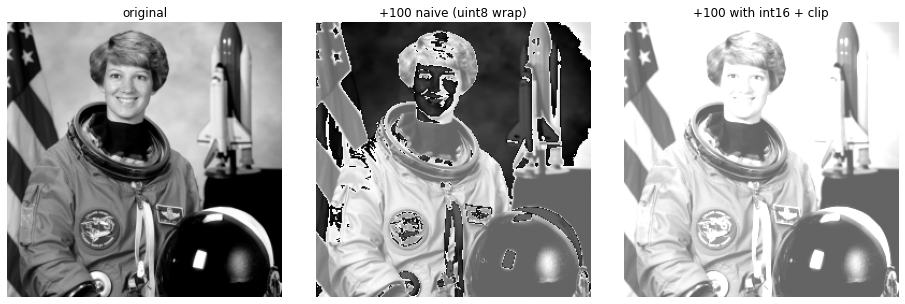

In [26]:
# The wrap-around trap, demonstrated
print("uint8 overflow:", np.uint8(200) + np.uint8(100), "  <- expected 300, got 44 (300 mod 256)")

naive  = img_array + 100                                              # WRONG: wraps around
safe   = np.clip(img_array.astype(np.int16) + 100, 0, 255).astype(np.uint8)   # CORRECT

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, (t, arr) in zip(ax, [("original", img_array),
                            ("+100 naive (uint8 wrap)", naive),
                            ("+100 with int16 + clip", safe)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

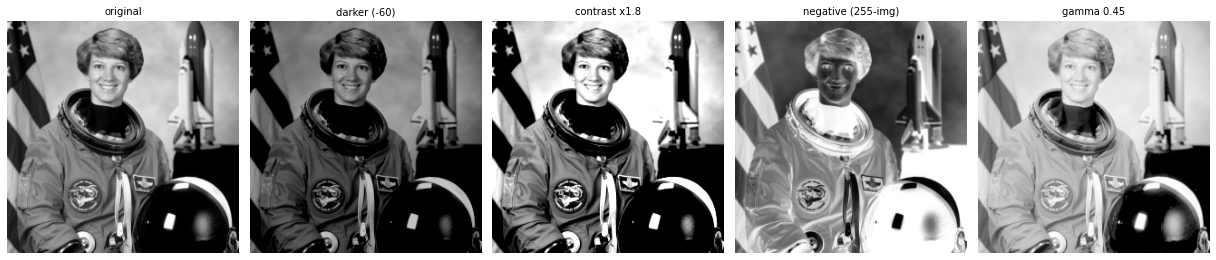

In [27]:
darker   = np.clip(img_array.astype(np.int16) - 60, 0, 255).astype(np.uint8)
contrast = np.clip((img_array.astype(np.float32) - 128) * 1.8 + 128, 0, 255).astype(np.uint8)
negative = 255 - img_array                                    # safe: result always in [0, 255]
gamma    = np.clip(((img_array / 255.0) ** 0.45) * 255, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 5, figsize=(17, 3.8))
for a, (t, arr) in zip(ax, [("original", img_array), ("darker (-60)", darker),
                            ("contrast x1.8", contrast), ("negative (255-img)", negative),
                            ("gamma 0.45", gamma)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=10); a.axis('off')
plt.tight_layout(); plt.show()

### A4 — Boolean masking and thresholding
A comparison on an array produces a **boolean array of the same shape** — a mask. This is the basis of segmentation.

mask dtype: bool | shape: (256, 256)
pixels brighter than 100: 39,125 of 65,536 (59.7%)


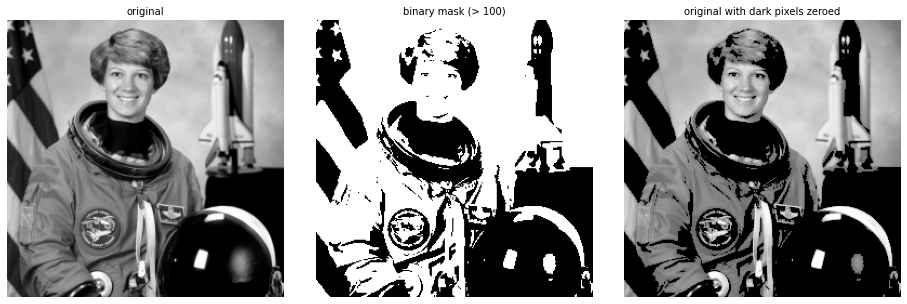

In [28]:
T = 100
mask = img_array > T                       # boolean array, same shape
binary = (mask * 255).astype(np.uint8)     # convert True/False to white/black

print("mask dtype:", mask.dtype, "| shape:", mask.shape)
print(f"pixels brighter than {T}: {mask.sum():,} of {mask.size:,} ({100*mask.mean():.1f}%)")

masked = img_array.copy()
masked[~mask] = 0                          # keep only the bright pixels

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, (t, arr) in zip(ax, [("original", img_array),
                            (f"binary mask (> {T})", binary),
                            ("original with dark pixels zeroed", masked)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=10); a.axis('off')
plt.tight_layout(); plt.show()

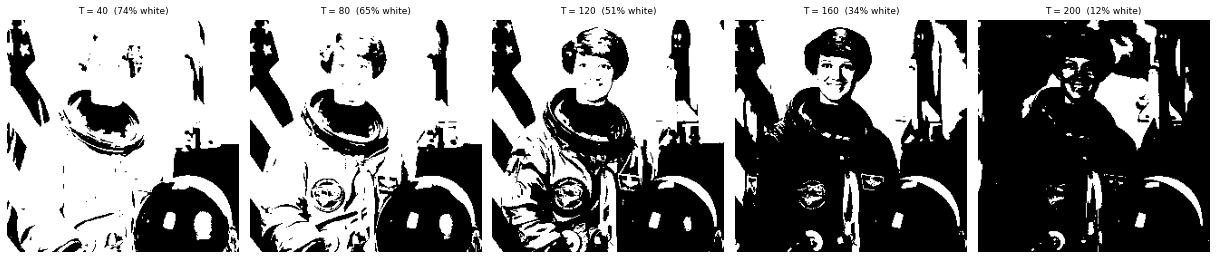

In [29]:
# Several thresholds at once
fig, ax = plt.subplots(1, 5, figsize=(17, 3.6))
for a, t in zip(ax, [40, 80, 120, 160, 200]):
    a.imshow((img_array > t) * 255, cmap='gray', vmin=0, vmax=255)
    a.set_title(f"T = {t}  ({100*(img_array > t).mean():.0f}% white)", fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

### A5 — Statistics and the histogram
Aggregation functions reduce the array to numbers that describe the image. The **histogram** counts how many pixels hold each gray level — it is the image's intensity distribution.

In [30]:
print(f"min       : {img_array.min()}")
print(f"max       : {img_array.max()}")
print(f"mean      : {img_array.mean():.2f}")
print(f"median    : {np.median(img_array):.2f}")
print(f"std dev   : {img_array.std():.2f}")
print(f"variance  : {img_array.var():.2f}")
print(f"sum       : {img_array.sum():,}")
print(f"25/50/75 percentiles: {np.percentile(img_array, [25, 50, 75])}")

# Per-axis aggregation: mean brightness of each row / column
print("\nmean of first 5 rows   :", img_array.mean(axis=1)[:5].round(2))
print("mean of first 5 columns:", img_array.mean(axis=0)[:5].round(2))

min       : 0
max       : 254
mean      : 112.70
median    : 123.00
std dev   : 74.37
variance  : 5530.60
sum       : 7,385,832
25/50/75 percentiles: [ 39. 123. 179.]

mean of first 5 rows   : [162.96 163.98 164.55 164.63 165.19]
mean of first 5 columns: [114.9  112.04 110.12 106.73 101.69]


hist.shape = (256,) | total counts = 65536 = number of pixels
most common gray level: 0 with 6884 pixels


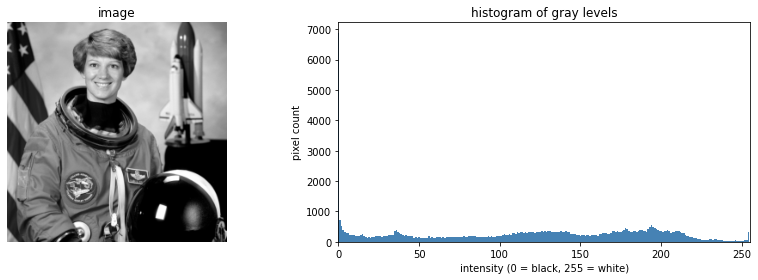

In [31]:
hist, bins = np.histogram(img_array, bins=256, range=(0, 256))
print("hist.shape =", hist.shape, "| total counts =", hist.sum(), "= number of pixels")
print("most common gray level:", hist.argmax(), "with", hist.max(), "pixels")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(img_array, cmap='gray', vmin=0, vmax=255); ax[0].set_title("image"); ax[0].axis('off')
ax[1].bar(bins[:-1], hist, width=1.0, color='steelblue')
ax[1].set_title("histogram of gray levels")
ax[1].set_xlabel("intensity (0 = black, 255 = white)"); ax[1].set_ylabel("pixel count")
ax[1].set_xlim(0, 255)
plt.tight_layout(); plt.show()

### A6 — Reshaping, stacking and building a colour image from channels
A colour image is simply a **3-D array** of shape `(height, width, 3)`. Stacking three 2-D arrays produces one.

original shape : (256, 256) -> ndim = 2
flattened      : (65536,) (all pixels in one long vector)
restored       : (256, 256)
as 512x128     : (512, 128) (same data, reinterpreted grid)

stacked colour image shape: (256, 256, 3)


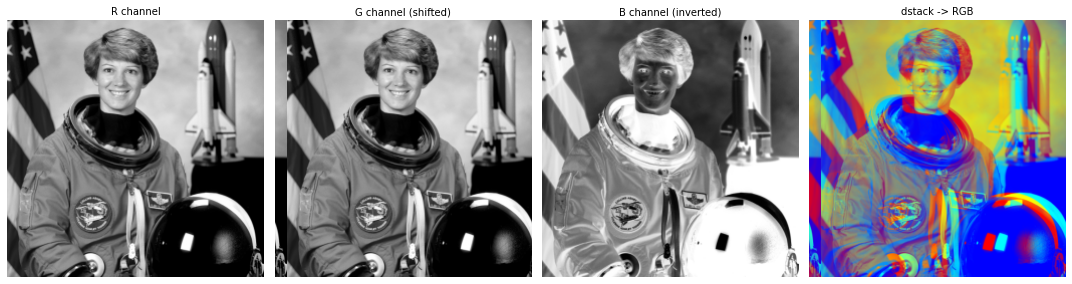

In [32]:
print("original shape :", img_array.shape, "-> ndim =", img_array.ndim)

flat = img_array.reshape(-1)
print("flattened      :", flat.shape, "(all pixels in one long vector)")
print("restored       :", flat.reshape(256, 256).shape)
print("as 512x128     :", img_array.reshape(512, 128).shape, "(same data, reinterpreted grid)")

# Stack three modified copies as R, G, B channels -> a colour image
R = img_array
G = np.roll(img_array, 12, axis=1)     # shift the green channel sideways
B = 255 - img_array                    # invert the blue channel
colour = np.dstack([R, G, B])          # (256, 256, 3)

print("\nstacked colour image shape:", colour.shape)

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (t, arr, cmap) in zip(ax, [("R channel", R, 'gray'), ("G channel (shifted)", G, 'gray'),
                                  ("B channel (inverted)", B, 'gray'), ("dstack -> RGB", colour, None)]):
    a.imshow(arr, cmap=cmap, vmin=None if cmap is None else 0, vmax=None if cmap is None else 255)
    a.set_title(t, fontsize=10); a.axis('off')
plt.tight_layout(); plt.show()

hstack shape: (256, 512) | vstack shape: (512, 512)


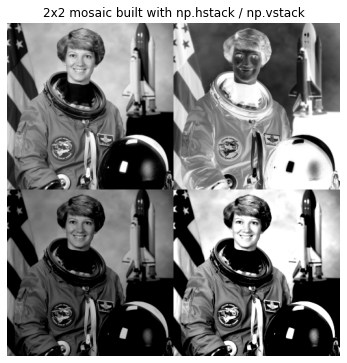

In [33]:
# Concatenation: tile images side by side and top to bottom
row = np.hstack([img_array, negative])                # horizontal
col = np.vstack([row, np.hstack([darker, contrast])]) # then vertical
print("hstack shape:", row.shape, "| vstack shape:", col.shape)

plt.figure(figsize=(6, 6))
plt.imshow(col, cmap='gray', vmin=0, vmax=255)
plt.title("2x2 mosaic built with np.hstack / np.vstack"); plt.axis('off'); plt.show()

### A7 — Downsampling with strided slicing, and blending two images

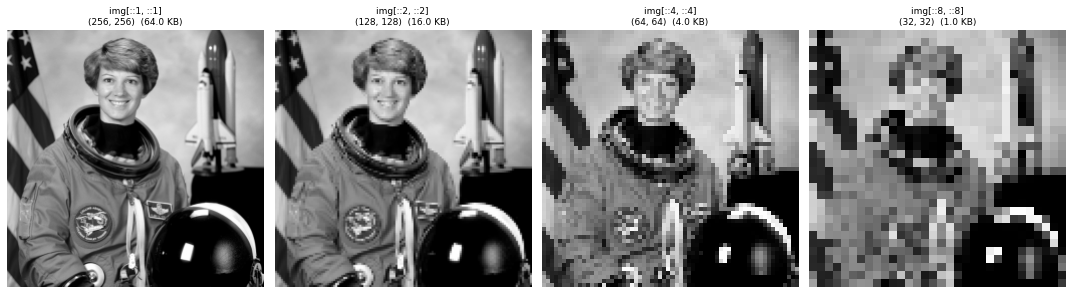

In [34]:
# Downsampling by taking every n-th pixel
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, step in zip(ax, [1, 2, 4, 8]):
    small = img_array[::step, ::step]
    a.imshow(small, cmap='gray', vmin=0, vmax=255)
    a.set_title(f"img[::{step}, ::{step}]\n{small.shape}  ({small.nbytes/1024:.1f} KB)", fontsize=9)
    a.axis('off')
plt.tight_layout(); plt.show()

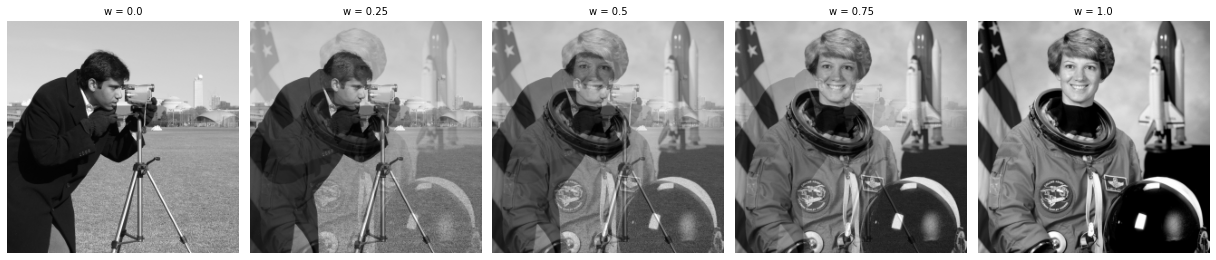

In [35]:
# Blending two images: a weighted average of two arrays
other = cv2.resize(img_gray, (256, 256))          # cameraman resized to match

fig, ax = plt.subplots(1, 5, figsize=(17, 3.8))
for a, w in zip(ax, [0.0, 0.25, 0.5, 0.75, 1.0]):
    blend = np.clip(w * img_array.astype(np.float32) +
                    (1 - w) * other.astype(np.float32), 0, 255).astype(np.uint8)
    a.imshow(blend, cmap='gray', vmin=0, vmax=255)
    a.set_title(f"w = {w}", fontsize=10); a.axis('off')
plt.tight_layout(); plt.show()

### A8 — Data types: `uint8` vs `float`
Many library functions return floats in `[0, 1]`; display and file I/O expect `uint8` in `[0, 255]`. Converting between them correctly is a constant source of bugs.

In [36]:
as_float = img_array.astype(np.float32) / 255.0
back     = (as_float * 255).astype(np.uint8)

print(f"uint8   : dtype={img_array.dtype}, range [{img_array.min()}, {img_array.max()}], {img_array.nbytes:,} bytes")
print(f"float32 : dtype={as_float.dtype}, range [{as_float.min():.3f}, {as_float.max():.3f}], {as_float.nbytes:,} bytes")
print("round-trip lossless?", np.array_equal(back, img_array))
print("\nfloat32 costs 4x the memory — keep images as uint8 unless computation requires floats.")

uint8   : dtype=uint8, range [0, 254], 65,536 bytes
float32 : dtype=float32, range [0.000, 0.996], 262,144 bytes
round-trip lossless? True

float32 costs 4x the memory — keep images as uint8 unless computation requires floats.


---
## 5 — Resources

* **NumPy cheat sheet** — <https://numpy.org/doc/stable/user/absolute_beginners.html>
* **Python basics cheat sheet** — <https://docs.python.org/3/tutorial/>
* **scikit-image sample datasets** (source of the images used here) — <https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html>
* OpenCV Python tutorials — <https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html>
* Pillow handbook — <https://pillow.readthedocs.io/>

---

## Conclusion — Outcome #1 addressed

**How digital images are represented in a computer**
A digital image is a rectangular **NumPy array of integers**. A grayscale image is 2-D with shape `(height, width)`;
a colour image is 3-D with shape `(height, width, 3)`. Each element is a **pixel**, a light-intensity sample
quantised to 8 bits, so it holds a value in `0–255` where 0 is black and 255 is white. The index `[row, col]`
gives the pixel's spatial position, with the origin at the **top-left** corner. Total storage is
`height × width × channels` bytes — for `lena_gray_256.tif`, 256 × 256 × 1 = 65,536 bytes.

**How digital images are manipulated**
Because the image *is* an array, every operation in this lab reduced to array arithmetic:

| Operation | NumPy mechanism |
|---|---|
| Crop, zoom, region-of-interest | slicing — `img[r0:r1, c0:c1]` |
| Flip, rotate, transpose | index reversal — `img[::-1]`, `img.T`, `np.rot90` |
| Brightness, contrast, gamma | scalar arithmetic + `np.clip` |
| Negative | `255 - img` |
| Thresholding / segmentation | boolean masks — `img > T` |
| Downsampling | strided slicing — `img[::n, ::n]` |
| Blending | weighted sum of two arrays |
| Histogram / statistics | `np.histogram`, `.mean()`, `.std()` |
| Colour construction | `np.dstack` of three 2-D channels |

**Three practical lessons recorded from this session**
1. `cv2.imread` returns channels in **BGR** order and forces 3 channels by default — convert with `cv2.cvtColor(..., cv2.COLOR_BGR2RGB)` before passing to Matplotlib, or read with `cv2.IMREAD_GRAYSCALE`.
2. `uint8` arithmetic **wraps around** (200 + 100 = 44). Cast to a wider type, compute, `np.clip` to [0, 255], then cast back.
3. **JPEG is lossy** — saving and reloading does not return the original pixel values. Use TIF or PNG when exact pixel data matters.
